<a href="https://colab.research.google.com/github/F-Abir/GEE-Python-API/blob/main/SVI_VIIRS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import ee
import geemap

In [2]:
import xarray as xr

In [ ]:
!pip install xee
import xee

In [4]:
ee.Authenticate()
ee.Initialize(
    project = 'ee-abirnahraf',
    opt_url = 'https://earthengine-highvolume.googleapis.com'
)

In [ ]:
map = geemap.Map(basemap = 'ROADMAP')
map

In [6]:
point = map.draw_last_feature.geometry()

In [9]:
roi = ee.FeatureCollection("FAO/GAUL/2015/level0").filterBounds(point).geometry().simplify(1000)

In [10]:
map.addLayer(roi, {}, 'roi')

In [11]:
evi = (
    ee.ImageCollection("NASA/VIIRS/002/VNP13A1")
    .filterDate('2015','2025')
    .select('EVI')
    .map(lambda x: x.clip(roi).copyProperties(x, ['system:time_start']))
)

In [12]:
ds = xr.open_dataset(
    evi,
    engine = 'ee',
    crs = 'EPSG:4326',
    geometry = roi,
    scale = 0.01
)

In [13]:
ds = ds.sortby('time') * 1

In [14]:
ds_mean = ds.mean(dim = 'time')
ds_std = ds.std(dim = 'time')

In [15]:
svi = (ds - ds_mean) / ds_std

In [16]:
svi_annual = svi.resample(time = 'Y').mean('time')

In [17]:
import matplotlib.pyplot as plt


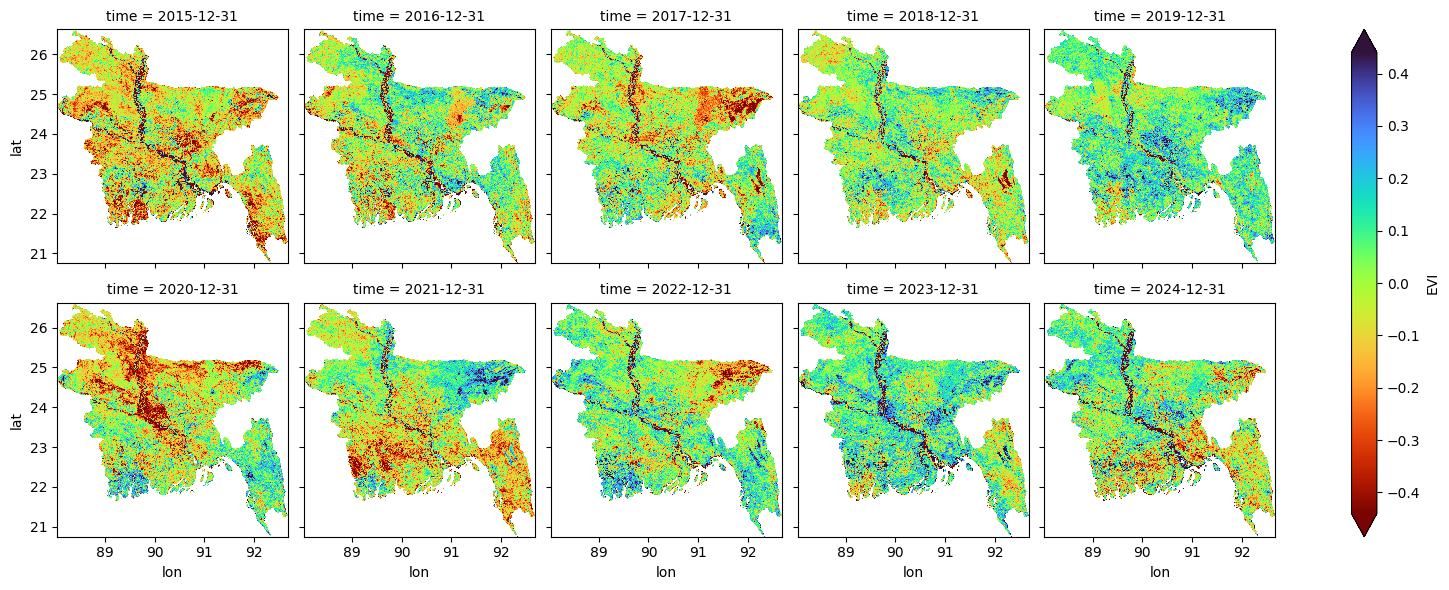

In [18]:
svi_annual.EVI.plot(
    x = 'lon',
    y = 'lat',
    col = 'time',
    col_wrap = 5,
    cmap = 'turbo_r',
    robust = True
)

In [ ]:
!pip install netCDF4
import netCDF4

In [20]:
svi_annual.to_netcdf('svi_annual_array.nc')


In [21]:
svi_annual_mean = svi_annual.mean(dim = ['lon', 'lat'])

In [22]:
svi_annual_df = svi_annual_mean.to_dataframe().dropna()

In [23]:
svi_annual_df.to_csv('svi_annual.csv')

<Axes: xlabel='time'>

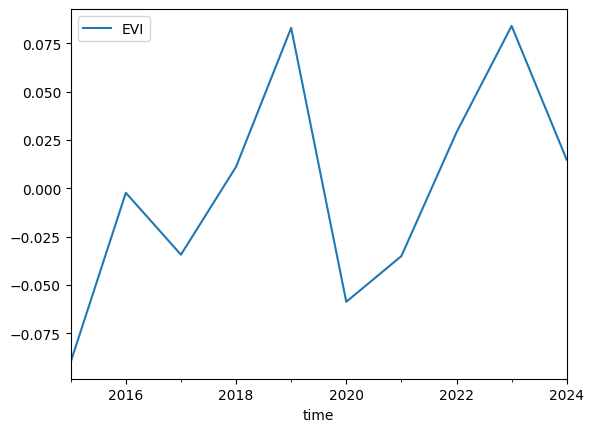

In [24]:
svi_annual_df.plot()

In [25]:
svi_mean = svi.mean(dim = ['lon', 'lat'])

In [26]:
svi_mean_df = svi_mean.to_dataframe().dropna()

In [28]:
svi_mean_df.to_csv('svi_16days.csv')

In [29]:
from google.colab import files
files.download('svi_16days.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Axes: xlabel='time'>

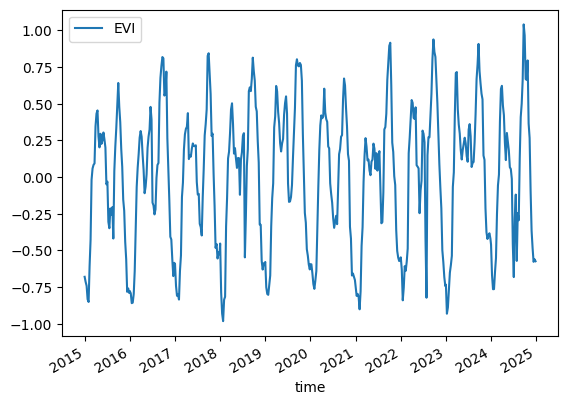

In [30]:
svi_mean_df.plot()